📋 미국 주식 리스트 추출 중 (S&P 500 Top 300)...
   ✅ S&P 500 종목 300개 추출 성공 (Wikipedia Direct)
🚀 총 300개 종목 분석 시작 (미국 주식 + 10년 치 데이터 + 순수 기술적 분석)
🔄 [USA Market - Pure Technical] 초대규모 데이터 수집 시작 (10년 치)...
🎯 대상 종목 수: 300개 (목표 데이터: 30만 개 이상)
🎯 성공 기준: 5일 '이내' 최고가가 ATR x 1.3 달성 시 성공
   ... 진행 중 (50/300)
   ... 진행 중 (100/300)
   ... 진행 중 (150/300)
   ... 진행 중 (200/300)
   ... 진행 중 (250/300)
   ... 진행 중 (300/300)
✅ 데이터 준비 완료! 총 샘플 수: 696,432개
📊 전체 데이터 중 '성공(Target=1)' 비율: 39.0%

🧠 AI 학습 시작 (순수 기술적 지표)...
📌 학습에 사용되는 총 변수(Feature) 개수: 19개

🎓 [모델 평가 - Pure Technical]
-----------------------------------------------------------------
Threshold  | Precision (승률)  | Trade Count  | 비고
-----------------------------------------------------------------
 50% 이상  |         43.45%   | 61,336회     | 
 55% 이상  |         47.77%   | 13,711회     | ⭐ 의미 있음
 60% 이상  |         55.79%   |  1,685회     | ⭐ 의미 있음
 65% 이상  |         79.56%   |    225회     | ⭐ 의미 있음
 70% 이상  |         84.27%   |     89회     | ⭐ 의미 있음
 80% 이상  |    

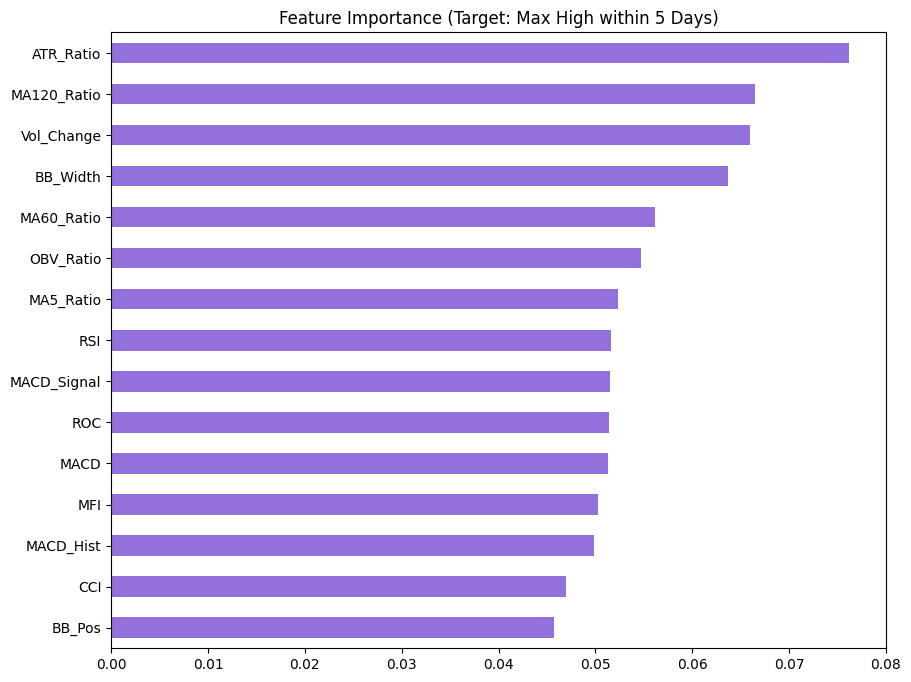

In [15]:
import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score
from datetime import datetime, timedelta
import warnings
import requests
import io

# 경고 메시지 끄기
warnings.filterwarnings('ignore')

# =========================================================
# [설정] 모델 학습 기준 (미국 주식 + 기술적 분석 집중)
# =========================================================
PREDICTION_DAYS = 5         # 5일 이내 달성 여부 확인
TARGET_ATR_MULTIPLIER = 1.3 # 목표 수익률 (ATR의 1.3배)
# =========================================================

class StockMLPredictorTechnical:
    def __init__(self, tickers):
        self.tickers = tickers
        self.data = pd.DataFrame()
        
        # 분석할 기본 지표 목록 정의
        self.base_indicators = [
            'MA5_Ratio', 'MA20_Ratio', 'MA60_Ratio', 'MA120_Ratio',
            'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
            'BB_Width', 'BB_Pos', 'Stoch_K', 
            'CCI', 'WillR', 'OBV_Ratio', 'MFI',
            'ROC', 'Vol_Change', 'ATR_Ratio', 'Disparity'
        ]
        
        self.model = RandomForestClassifier(
            n_estimators=300, 
            max_depth=15, # 데이터가 많아졌으니 깊이를 늘림
            random_state=42, 
            class_weight='balanced',
            n_jobs=-1
        )
        
    def calc_technical_indicators(self, df):
        """20개 핵심 기술적 지표 계산"""
        # 1. 이동평균 이격도
        for window in [5, 20, 60, 120]:
            ma = df['Close'].rolling(window).mean()
            df[f'MA{window}_Ratio'] = df['Close'] / ma

        # 2. RSI
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # 3. MACD
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
        
        # 4. 볼린저 밴드
        sma20 = df['Close'].rolling(20).mean()
        std20 = df['Close'].rolling(20).std()
        upper = sma20 + (std20 * 2)
        lower = sma20 - (std20 * 2)
        df['BB_Width'] = (upper - lower) / sma20
        df['BB_Pos'] = (df['Close'] - lower) / (upper - lower)
        
        # 5. 거래량 변화율 & OBV
        if 'Volume' in df.columns:
            vol = df['Volume'].replace(0, np.nan).ffill()
            df['Vol_Change'] = vol / vol.rolling(20).mean()
            
            direction = np.sign(df['Close'].diff()).fillna(0)
            obv = (vol * direction).cumsum()
            df['OBV_Ratio'] = obv / obv.rolling(20).mean()
            
        # 6. ATR (변동성)
        if 'High' in df.columns:
            tr = pd.concat([
                df['High'] - df['Low'],
                (df['High'] - df['Close'].shift(1)).abs(),
                (df['Low'] - df['Close'].shift(1)).abs()
            ], axis=1).max(axis=1)
            atr = tr.rolling(14).mean()
            df['ATR_Ratio'] = atr / df['Close']
            
        # 7. Stochastic
        low_min = df['Low'].rolling(14).min()
        high_max = df['High'].rolling(14).max()
        df['Stoch_K'] = ((df['Close'] - low_min) / (high_max - low_min)) * 100
        
        # 8. CCI
        tp = (df['High'] + df['Low'] + df['Close']) / 3
        df['CCI'] = (tp - tp.rolling(20).mean()) / (0.015 * (tp - tp.rolling(20).mean()).abs().rolling(20).mean())
        
        # 9. Williams %R
        df['WillR'] = (high_max - df['Close']) / (high_max - low_min) * -100
        
        # 10. MFI
        rmf = tp * vol
        pos_mf = pd.Series(np.where(df['Close'].diff() > 0, rmf, 0), index=df.index).rolling(14).sum()
        neg_mf = pd.Series(np.where(df['Close'].diff() < 0, rmf, 0), index=df.index).rolling(14).sum()
        df['MFI'] = 100 - (100 / (1 + (pos_mf / neg_mf)))
        
        # 11. ROC
        df['ROC'] = df['Close'].pct_change(periods=10) * 100
        
        # 12. Disparity
        df['Disparity'] = (df['Close'] / sma20) * 100

        return df

    def fetch_and_prepare_data(self):
        # [수정] 5년 -> 10년으로 확장
        years = 10
        print(f"🔄 [USA Market - Pure Technical] 초대규모 데이터 수집 시작 ({years}년 치)...")
        print(f"🎯 대상 종목 수: {len(self.tickers)}개 (목표 데이터: 30만 개 이상)")
        print(f"🎯 성공 기준: {PREDICTION_DAYS}일 '이내' 최고가가 ATR x {TARGET_ATR_MULTIPLIER} 달성 시 성공")
        
        all_data = []
        start_date = (datetime.now() - timedelta(days=365*years)).strftime('%Y-%m-%d')
        
        count = 0
        total = len(self.tickers)

        for ticker in self.tickers:
            count += 1
            if count % 50 == 0: print(f"   ... 진행 중 ({count}/{total})")

            try:
                # 미국 주식은 FDR에서 티커 그대로 사용
                df = fdr.DataReader(ticker, start_date)
                
                if df.empty or len(df) < 200: continue
                required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                if not all(col in df.columns for col in required_cols): continue
                
                df = df[required_cols].copy()
                df = df.apply(pd.to_numeric, errors='coerce')
                
                # 1. 기본 지표 계산
                df = self.calc_technical_indicators(df)
                
                # 2. Target 생성 (High Water Mark 방식)
                future_highs = pd.concat([df['High'].shift(-i) for i in range(1, PREDICTION_DAYS + 1)], axis=1)
                max_future_high = future_highs.max(axis=1)
                
                # 최고가 기준 수익률 계산
                max_future_return = max_future_high / df['Close'] - 1
                
                threshold = df['ATR_Ratio'] * TARGET_ATR_MULTIPLIER
                df['Target'] = (max_future_return > threshold).astype(int)
                
                # 결측치 제거
                df_clean = df.dropna().copy()
                
                if not df_clean.empty:
                    df_clean['Ticker'] = ticker
                    all_data.append(df_clean)
                    
            except Exception:
                continue
                
        if not all_data:
            print("❌ 데이터 수집 실패: 유효한 데이터가 없습니다.")
            return False
            
        self.data = pd.concat(all_data)
        print(f"✅ 데이터 준비 완료! 총 샘플 수: {len(self.data):,}개")
        print(f"📊 전체 데이터 중 '성공(Target=1)' 비율: {self.data['Target'].mean()*100:.1f}%")
        
        return True

    def train_model(self):
        if self.data.empty: return
        print("\n🧠 AI 학습 시작 (순수 기술적 지표)...")
        
        # 학습에 사용할 컬럼 (기본 지표만 사용)
        features = [col for col in self.data.columns 
                   if col in self.base_indicators]
        
        print(f"📌 학습에 사용되는 총 변수(Feature) 개수: {len(features)}개")
        
        X = self.data[features]
        y = self.data['Target']
        
        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]
        
        self.model.fit(X_train, y_train)
        y_proba = self.model.predict_proba(X_test)[:, 1]
        
        print(f"\n🎓 [모델 평가 - Pure Technical]")
        print("-" * 65)
        print(f"{'Threshold':<10} | {'Precision (승률)':<15} | {'Trade Count':<12} | {'비고'}")
        print("-" * 65)
        
        best_acc = 0
        
        for th in [0.5, 0.55, 0.6, 0.65, 0.7, 0.8]:
            preds = (y_proba >= th).astype(int)
            prec = precision_score(y_test, preds, zero_division=0)
            cnt = preds.sum()
            
            note = ""
            if cnt > 50 and prec > 0.45: note = "⭐ 의미 있음"
            if prec > best_acc and cnt > 20: best_acc = prec
            
            print(f"{th*100:>3.0f}% 이상  | {prec*100:>13.2f}%   | {cnt:>6,}회     | {note}")
            
        print("-" * 65)
        
        # 중요도 시각화
        importances = pd.Series(self.model.feature_importances_, index=features).sort_values(ascending=False)
        print("\n🏆 [AI 선정] 순수 기술적 지표 TOP 10")
        # [수정] 짤리지 않고 명확하게 보이도록 포맷팅 출력
        top10 = importances.head(10)
        for i, (name, score) in enumerate(top10.items(), 1):
            print(f"{i:>2}. {name:<15} : {score:.6f}")
        
        plt.figure(figsize=(10, 8))
        importances.head(15).plot(kind='barh', color='mediumpurple')
        plt.title('Feature Importance (Target: Max High within 5 Days)')
        plt.gca().invert_yaxis()
        plt.show()

def get_top_tickers():
    """S&P 500 및 주요 미국 기술주 리스트 추출"""
    tickers = []
    print("📋 미국 주식 리스트 추출 중 (S&P 500 Top 300)...")
    
    try:
        # Wikipedia에서 직접 스크래핑
        url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }
        
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        
        df_list = pd.read_html(io.StringIO(response.text))
        df_sp500 = df_list[0]
        
        # [수정] 상위 100개 -> 300개로 확대
        sp500_tickers = df_sp500['Symbol'].head(300).tolist()
        sp500_tickers = [t.replace('.', '-') for t in sp500_tickers]
        
        tickers.extend(sp500_tickers)
        print(f"   ✅ S&P 500 종목 {len(sp500_tickers)}개 추출 성공 (Wikipedia Direct)")
        
    except Exception as e:
        print(f"⚠️ 자동 리스트 추출 실패 ({e}) -> 백업 리스트(Manual) 사용")
        tickers = [
            'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA', 'META', 'BRK-B', 'UNH', 'JNJ',
            'XOM', 'V', 'PG', 'HD', 'JPM', 'MA', 'CVX', 'ABBV', 'MRK', 'PEP',
            'KO', 'LLY', 'AVGO', 'COST', 'TMO', 'MCD', 'CSCO', 'ACN', 'ABT', 'DHR',
            'DIS', 'LIN', 'TXN', 'WMT', 'ADBE', 'PM', 'NEE', 'NKE', 'VZ', 'CRM',
            'AMD', 'NFLX', 'INTC', 'QCOM', 'IBM', 'BA', 'HON', 'AMGN', 'RTX', 'SBUX'
        ]
        
    return tickers

if __name__ == "__main__":
    target_tickers = get_top_tickers()
    print(f"🚀 총 {len(target_tickers)}개 종목 분석 시작 (미국 주식 + 10년 치 데이터 + 순수 기술적 분석)")
    
    predictor = StockMLPredictorTechnical(target_tickers)
    if predictor.fetch_and_prepare_data():
        predictor.train_model()

🔮 [실전] S&P 500 전 종목 스캔 및 확률 계산 중... (잠시만 기다려주세요)
🎯 분석 대상: 503개 종목
   ... 50/503 분석 중
   ... 100/503 분석 중
   ... 150/503 분석 중
   ... 200/503 분석 중
   ... 250/503 분석 중
   ... 300/503 분석 중
   ... 350/503 분석 중
   ... 400/503 분석 중
   ... 450/503 분석 중
   ... 500/503 분석 중

🏆 [AI 선정] 5일 내 목표가(ATR 1.3배) 달성 확률 TOP 10
기준일: 2026-01-08
순위   종목              현재가      성공확률(%) AI 판독
------------------------------------------------------------
1    WRB      $    70.24        59.0%    👀 관심
2    WBD      $    28.32        58.9%    👀 관심
3    T        $    24.17        58.8%    👀 관심
4    FE       $    44.69        58.3%    👀 관심
5    MCK      $   814.63        58.2%    👀 관심
6    REG      $    70.62        58.0%    👀 관심
7    TRV      $   284.18        58.0%    👀 관심
8    L        $   105.49        57.5%    👀 관심
9    SPG      $   184.98        57.2%    👀 관심
10   PPL      $    34.67        57.1%    👀 관심


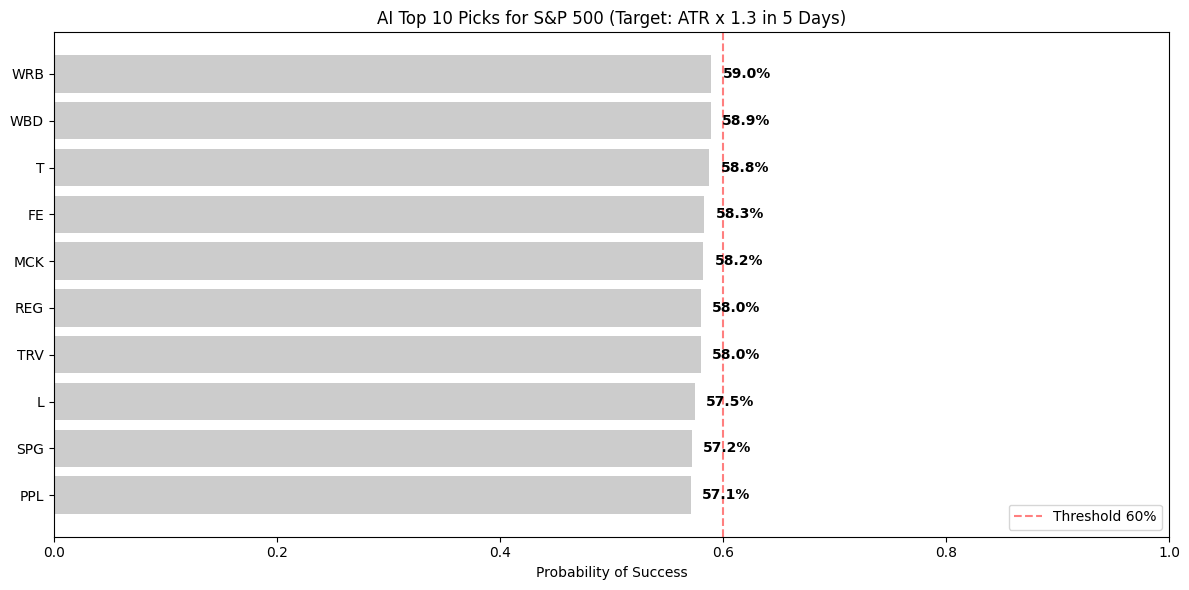

In [16]:
# ---------------------------------------------------------
# [Cell 2] 실전 예측: 학습된 모델로 "내일의 급등주" 발굴하기
# * 주의: 위 셀(학습 코드)이 먼저 완료되어 'predictor' 객체가 있어야 합니다.
# ---------------------------------------------------------
import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
from datetime import datetime, timedelta

def get_full_sp500_tickers():
    """S&P 500 전체 종목 리스트 가져오기 (예측용)"""
    try:
        url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers)
        df_list = pd.read_html(io.StringIO(response.text))
        tickers = df_list[0]['Symbol'].tolist()
        return [t.replace('.', '-') for t in tickers] # BRK.B -> BRK-B 변환
    except:
        return []

def predict_top_stocks(model_instance, top_n=10):
    print(f"🔮 [실전] S&P 500 전 종목 스캔 및 확률 계산 중... (잠시만 기다려주세요)")
    
    # 1. 전체 종목 리스트 확보
    scan_tickers = get_full_sp500_tickers()
    if not scan_tickers:
        scan_tickers = model_instance.tickers # 실패 시 학습했던 리스트 재사용
    
    print(f"🎯 분석 대상: {len(scan_tickers)}개 종목")
    
    predictions = []
    # 지표 계산을 위해 최근 1년치 데이터만 가져옴 (속도 최적화)
    start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')
    
    count = 0
    total = len(scan_tickers)
    
    for ticker in scan_tickers:
        count += 1
        if count % 50 == 0: print(f"   ... {count}/{total} 분석 중")
            
        try:
            # 데이터 수집
            df = fdr.DataReader(ticker, start_date)
            # 데이터가 너무 적으면 지표 계산 불가 (최소 120일)
            if df.empty or len(df) < 120: continue
            
            # 전처리 (학습 때와 동일하게)
            required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
            if not all(col in df.columns for col in required_cols): continue
            
            df = df[required_cols].copy()
            df = df.apply(pd.to_numeric, errors='coerce')
            
            # 지표 계산 (학습된 클래스의 메서드 재사용)
            df = model_instance.calc_technical_indicators(df)
            
            # [핵심] 가장 최근(오늘) 데이터 추출
            last_row = df.iloc[[-1]]
            current_date = last_row.index[-1].strftime('%Y-%m-%d')
            current_price = last_row['Close'].values[0]
            
            # 학습에 사용된 Feature만 정확히 추출 (순서 중요)
            features = [col for col in model_instance.data.columns 
                       if col in model_instance.base_indicators]
            
            X_new = last_row[features]
            
            # 결측치가 하나라도 있으면 예측 불가
            if X_new.isnull().values.any(): continue
            
            # 확률 예측 (1: 상승일 확률)
            prob = model_instance.model.predict_proba(X_new)[0, 1]
            
            predictions.append({
                'Ticker': ticker,
                'Date': current_date,
                'Close': current_price,
                'Probability': prob
            })
            
        except Exception as e:
            continue
            
    # 결과 정렬 (확률 높은 순)
    if not predictions:
        print("❌ 예측된 종목이 없습니다.")
        return

    df_result = pd.DataFrame(predictions)
    df_result = df_result.sort_values(by='Probability', ascending=False).head(top_n)
    
    # --- 결과 리포트 출력 ---
    print("\n" + "="*60)
    print(f"🏆 [AI 선정] 5일 내 목표가(ATR 1.3배) 달성 확률 TOP {top_n}")
    print(f"기준일: {df_result.iloc[0]['Date']}")
    print("="*60)
    print(f"{'순위':<4} {'종목':<8} {'현재가':>10} {'성공확률(%)':>12} {'AI 판독'}")
    print("-" * 60)
    
    for i, row in enumerate(df_result.itertuples(), 1):
        # AI 의견
        comment = "관망"
        if row.Probability >= 0.7: comment = "🔥 강력매수"
        elif row.Probability >= 0.6: comment = "✨ 매수추천"
        elif row.Probability >= 0.5: comment = "👀 관심"
        
        print(f"{i:<4} {row.Ticker:<8} ${row.Close:>9.2f} {row.Probability*100:>11.1f}%    {comment}")
    print("="*60)
    
    # --- 시각화 (Horizontal Bar Chart) ---
    plt.figure(figsize=(12, 6))
    
    # 확률에 따른 색상 구분
    colors = []
    for p in df_result['Probability']:
        if p >= 0.7: colors.append('#ff3333')      # 빨강 (강력매수)
        elif p >= 0.6: colors.append('#ff9933')    # 주황 (매수추천)
        else: colors.append('#cccccc')             # 회색 (관심)
    
    bars = plt.barh(df_result['Ticker'], df_result['Probability'], color=colors)
    plt.axvline(x=0.6, color='red', linestyle='--', alpha=0.5, label='Threshold 60%')
    
    plt.xlabel('Probability of Success')
    plt.title(f'AI Top {top_n} Picks for S&P 500 (Target: ATR x 1.3 in 5 Days)')
    plt.xlim(0, 1.0)
    plt.gca().invert_yaxis() # 1위가 맨 위로 오게
    
    # 막대 옆에 수치 표시
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width*100:.1f}%', 
                 va='center', fontweight='bold')
        
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# 함수 실행 (앞 셀의 predictor 객체 사용)
if 'predictor' in globals():
    predict_top_stocks(predictor, top_n=10)
else:
    print("❌ 'predictor' 객체가 없습니다. 위 셀(모델 학습)을 먼저 실행해주세요.")